Importacao de todas as bibliotecas necessarias para o projeto:
  - pandas / numpy: manipulacao de dados e algebra numerica
  - matplotlib / seaborn: visualizacoes graficas
  - sklearn: pre-processamento, clustering e metricas de avaliacao
  - scipy: dendrograma hierarquico
  - hashlib: verificacao de integridade do ficheiro de dados (SHA-256)
  - pathlib.Path: criacao de diretorios de forma portavel





In [ ]:
#packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib, time, warnings, json
from pathlib import Path

from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    adjusted_rand_score, pairwise_distances_argmin)
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch

warnings.filterwarnings('ignore')
GLOBAL_SEED=42 #seed global
np.random.seed(GLOBAL_SEED)
sns.set_theme(style='whitegrid', palette='tab10') #estilo dos graficos
#whitegrid é o fundo branco com grelha atras, e tab10 são as cores padrao

for folder in ['figures', 'tables']: #cria pastas para figuras e tabelas
    Path(folder).mkdir(exist_ok=True) #nao da erro se ja existirem

## 1. Dataset Documentation

Carregamento do CSV de reservas de hotel (119 390 linhas x 32 colunas).
O SHA-256 e calculado antes de ler o ficheiro para verificar a integridade dos dados — garante que estamos sempre a usar exactamente a mesma versao do dataset, essencial para reproducibilidade.


In [ ]:
data = '/content/hotel_bookings_course_release_v1.csv'

#calcula hash SHA-256 do ficheiro (verificacao de integridade)
with open(data, 'rb') as f:
    sha256 = hashlib.sha256(f.read()).hexdigest()

df = pd.read_csv(data)
print(f'Shape: {df.shape[0]:,} linhas x {df.shape[1]} colunas')
#output:119,390 linhas x 32 colunas


Shape: 119,390 linhas x 32 colunas


## 2. Exploratory Data Analysis

Estatisticas descritivas basicas (head + describe) para ter uma primeira leitura dos dados: tipos de variaveis, ranges, possiveis outliers.

In [ ]:
#basic statistics
display(df.head(3)) #primeiras 3 linhas
display(df.describe().round(2)) #estatisticas descritivas

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02


,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119386.0,119390.00,119390.00,119390.00,119390.00,119390.00,103050.00,6797.00,119390.00,119390.00,119390.00,119390.00
mean,0.37,104.01,2016.16,27.17,15.80,0.93,2.50,1.86,0.1,0.01,0.03,0.09,0.14,0.22,86.69,189.27,2.32,101.83,0.06,0.57
std,0.48,106.86,0.71,13.61,8.78,1.00,1.91,0.58,0.4,0.10,0.18,0.84,1.50,0.65,110.77,131.66,17.59,50.54,0.25,0.79
min,0.00,0.00,2015.00,1.00,1.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,1.00,6.00,0.00,-6.38,0.00,0.00
25%,0.00,18.00,2016.00,16.00,8.00,0.00,1.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,9.00,62.00,0.00,69.29,0.00,0.00
50%,0.00,69.00,2016.00,28.00,16.00,1.00,2.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,14.00,179.00,0.00,94.58,0.00,0.00
75%,1.00,160.00,2017.00,38.00,23.00,2.00,3.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,229.00,270.00,0.00,126.00,0.00,1.00
max,1.00,737.00,2017.00,53.00,31.00,19.00,50.00,55.00,10.0,10.00,1.00,26.00,72.00,21.00,535.00,543.00,391.00,5400.00,8.00,5.00


In [ ]:
#Missingness report by attribute type

#identify numerical and categorical columns
numeric_raw=df.select_dtypes(include=['int64','float64']).columns.tolist() #int and float
categ_raw=df.select_dtypes(include=['object']).columns.tolist() #object

#count missing values for each column
miss=df.isnull().sum()
miss_pct=(miss/len(df)*100).round(2) #percentage of missing values
#summary table with number of missing values, the percentage and data type
miss_df=pd.DataFrame({'missing_n':miss,'missing_%':miss_pct, 'dtype':df.dtypes,'type':['num' if c in numeric_raw else 'cat'
                                                       for c in df.columns]})
#keep only columns with missing values and sort them
miss_df = miss_df[miss_df.missing_n>0].sort_values('missing_%', ascending=False)


display(miss_df)
print()

,missing_n,missing_%,dtype,type
company,112593,94.31,float64,num
agent,16340,13.69,float64,num
country,488,0.41,object,cat
children,4,0.00,float64,num


valores em falta por variavel:
  - 'company': 94% missing — identificador de alta cardinalidade, sera substituido por variavel binaria 'has_company'
  - 'agent': 14% missing — idem, sera substituido por 'has_agent'
  - 'country': 0.4% missing — preenchido com 'Unknown'
  - 'children': <0.01% missing — preenchido com 0


Analise de outliers nas variaveis numericas chave usando a regra do IQR:
  upper_fence = Q3 + 1.5 * IQR
Variaveis com forte assimetria positiva (right-skew) sao identificadas e visualizadas em histogramas com clip no percentil 99 (para nao distorcer o eixo).
Estas variaveis serao transformadas com log1p antes do clustering.


,mean,50%,max,IQR,upper_fence,outlier_%
lead_time,104.01,69.00,737.0,142.00,373.00,2.52
stays_in_week_nights,2.50,2.00,50.0,2.00,6.00,2.81
stays_in_weekend_nights,0.93,1.00,19.0,2.00,5.00,0.22
adults,1.86,2.00,55.0,0.00,2.00,5.26
children,0.10,0.00,10.0,0.00,0.00,7.19
babies,0.01,0.00,10.0,0.00,0.00,0.77
previous_cancellations,0.09,0.00,26.0,0.00,0.00,5.43
previous_bookings_not_canceled,0.14,0.00,72.0,0.00,0.00,3.03
total_of_special_requests,0.57,0.00,5.0,1.00,2.50,2.41
required_car_parking_spaces,0.06,0.00,8.0,0.00,0.00,6.21


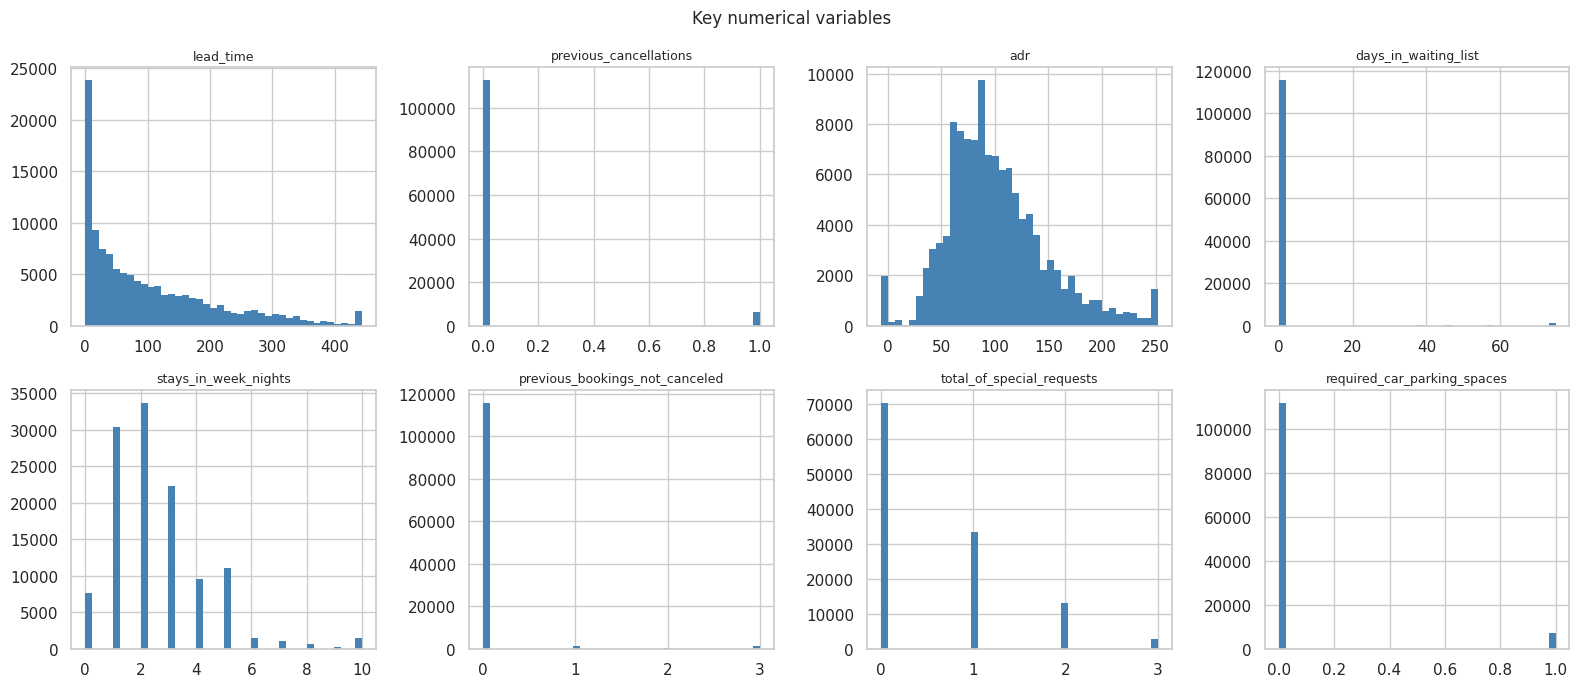

In [ ]:
#Outlier report & distribution plots

#select the main numerical variables for outlier analysis
#these variables are important for booking behavior, customer profile,
#and hotel reservation patterns
key_num = ['lead_time','stays_in_week_nights','stays_in_weekend_nights',
           'adults','children','babies','previous_cancellations',
           'previous_bookings_not_canceled','total_of_special_requests',
           'required_car_parking_spaces','adr']
#descriptive statistics
stats = df[key_num].describe(percentiles=[.25,.75,.95,.99]).T
stats['IQR']=stats['75%']-stats['25%'] #interquartile range
stats['upper_fence'] = stats['75%'] + 1.5 * stats['IQR'] #upper fence
stats['outlier_%']= [round((df[c] > stats.loc[c,'upper_fence']).mean()*100, 2) for c in key_num] #percentage of observations above the upper fence
display(stats[['mean','50%','max','IQR','upper_fence','outlier_%']].round(2)) #display

#create subplot grid for histogram visualization
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
#select variables with strong right-skewness because these usually require special treatment in modeling
skewed = ['lead_time','previous_cancellations','adr',
          'days_in_waiting_list','stays_in_week_nights',
          'previous_bookings_not_canceled','total_of_special_requests',
          'required_car_parking_spaces']
for ax, col in zip(axes.flat, skewed):
    clipped = df[col].clip(upper=df[col].quantile(0.99))
    ax.hist(clipped, bins=40, color='steelblue', edgecolor='none')
    ax.set_title(col, fontsize=9); ax.set_xlabel('')
plt.suptitle('Key numerical variables', fontsize=12)
plt.tight_layout()
plt.savefig('figures/eda_distributions.png', dpi=120, bbox_inches='tight') #guardar os graficos das distribuicoes
plt.show()

## 3. Feature Selection Table (RQ2)

Segmentation / index time = immediately after the initial booking is created.


## 4. Preprocessing Pipeline

In [ ]:
df2=df.copy()

#Remover linhas sem hospedes (problema de qualidade de dados)
no_guests = (df2['adults'] + df2['children'].fillna(0) + df2['babies']) == 0
print(f'Linhas com 0 hospedes removidas: {no_guests.sum()}')  # 180 linhas
df2 = df2[~no_guests].reset_index(drop=True)

#Imputar valores em falta
df2['children'] = df2['children'].fillna(0) #na coluna children
df2['country']  = df2['country'].fillna('Unknown') #nos paises

#criar novas features
df2['total_nights']=df2['stays_in_weekend_nights'] + df2['stays_in_week_nights'] #numero de noite
df2['party_size']=df2['adults'] + df2['children'] + df2['babies'] #quantas pessoas
df2['has_children']=((df2['children'] + df2['babies']) > 0).astype(int) #se tem ou nao criancas
df2['has_agent']=(df2['agent'].notna() & (df2['agent'] != 0)).astype(int) #se com ou agente ou nao
df2['has_company']=(df2['company'].notna() & (df2['company'] != 0)).astype(int) #se com company ou nao
df2['has_parking']= (df2['required_car_parking_spaces'] >= 1).astype(int) #se require parking

#agrupar paises: top-15 + Others para nao serem em quantidade enorme
TOP_N=15
top_countries=df2['country'].value_counts().head(TOP_N).index.tolist() #escolher os 15 top
df2['country_grouped']=df2['country'].apply(lambda x: x if x in top_countries else 'Other') #os outros ficam em others

#Refeicao undefined passa a ser sc
df2['meal_clean']=df2['meal'].replace({'Undefined': 'SC'})

# Cap em pedidos especiais (max 4)
df2['special_req_capped'] = df2['total_of_special_requests'].clip(upper=4)

#transformacoes log1p para variaveis com assimetria positiva (por causa dos outliers desta assimetria)
df2['lead_time_log']= np.log1p(df2['lead_time'])
df2['prev_cancel_log']= np.log1p(df2['previous_cancellations'])
df2['prev_not_cancel_log']= np.log1p(df2['previous_bookings_not_canceled'])

print(f'Dataset limpo: {df2.shape[0]:,} linhas x {df2.shape[1]} colunas') #tamanho dos dados ja com estas alteracoes


Linhas com 0 hospedes removidas: 180
Dataset limpo: 119,210 linhas x 44 colunas


Definicao dos conjuntos de features de input:
  NUMERICAL_FEATURES: transformadas com log1p e StandardScaler
  BINARY_FEATURES: passadas diretamente (0/1)
  CATEGORICAL_FEATURES: one-hot encoding


In [ ]:

#Feature sets

NUMERICAL_FEATURES = ['lead_time_log', #booking anticipation
    'total_nights', #stay length
    'party_size',  #group composition
    'prev_cancel_log', #cancellation history
    'prev_not_cancel_log', #loyalty signal
    'special_req_capped',]#service preferences
BINARY_FEATURES = ['has_children',#if has children
    'has_agent',  #booked via agent
    'has_company', #corporate booking
    'has_parking', ] #car-parking requested
CATEGORICAL_FEATURES = ['hotel', #holidays flag
    'meal_clean',  #what type of meal is consuming
    'market_segment', #if comes with a company etc
    'distribution_channel', #Online TA etc
    'deposit_type',#refundable or not
    'customer_type',
    'reserved_room_type',#can say a lot about the type of costumer
    'arrival_date_month',#sazonality holidays
    'country_grouped',]
ALL_INPUT = NUMERICAL_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES #juntar todos os inputs
print(f'Input features: {len(NUMERICAL_FEATURES)} numerical + {len(BINARY_FEATURES)} binary + {len(CATEGORICAL_FEATURES)} categorical')
print(f'Total raw input columns: {len(ALL_INPUT)}')
print()

Input features: 6 numerical + 4 binary + 9 categorical
Total raw input columns: 19



Construcao do ColumnTransformer com duas variantes de escalonamento:
  R0 (Standard): StandardScaler — outliers extremos podem alterar
  R1 (Robust): RobustScaler — mais resistente a outliers (usa mediana e IQR)
Pipeline numerico: imputa mediana -> escala
Pipeline categorico: imputa moda -> one-hot encoding
Resultado final: 73 dimensoes em ambas as representacoes


In [ ]:

#Build ColumnTransformer (R0:Standard, R1:Robust)

def build_preprocessor(scaler_type='standard'):
    sc=StandardScaler() if scaler_type == 'standard' else RobustScaler() #Criar os dois tipos de sacler
    num_pipe = Pipeline([ #pipeline numerico
        ('imputer', SimpleImputer(strategy='median')), #imputar com a median nos missing values
        ('scaler',  sc)
    ])
    cat_pipe = Pipeline([ #pipeline categorico
        ('imputer', SimpleImputer(strategy='most_frequent')),# imputar com a mode nos missing values
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    return ColumnTransformer([
        ('num', num_pipe, NUMERICAL_FEATURES), #para as numericas faz com o num pipe
        ('bin', 'passthrough',BINARY_FEATURES),
        ('cat', cat_pipe,CATEGORICAL_FEATURES), #para as categoricas faz com o cat pipe
    ])
#construir diferentes matrix
X_raw=df2[ALL_INPUT]
#com R0
prep_R0= build_preprocessor('standard')
X_R0= prep_R0.fit_transform(X_raw)
#com R1
prep_R1=build_preprocessor('robust')
X_R1=prep_R1.fit_transform(X_raw)

# Get feature names for distance contribution analysis
ohe_names = prep_R0.named_transformers_['cat']['ohe'] \
               .get_feature_names_out(CATEGORICAL_FEATURES).tolist()
FEATURE_NAMES = NUMERICAL_FEATURES + BINARY_FEATURES + ohe_names

print(f'final R0:{X_R0.shape}')
print(f'final R1:{X_R1.shape}')

final R0:(119210, 73)
final R1:(119210, 73)


Calcula a distancia euclidiana media por bloco (numerico, binario, categorico) em 500 pares aleatorios de uma amostra de 2000 observacoes.
Resultado: Numerico 59.6%, Binario 2.7%, Categorico 37.7%
Nenhum bloco ultrapassa 60% — representacao equilibrada, sem necessidade de rebalancear pesos.


In [ ]:
np.random.seed(GLOBAL_SEED)
s_idx= np.random.choice(len(X_R0), size=2000, replace=False) #escolhe 2000 indices aleatorios
X_samp= X_R0[s_idx] #e escolhe esses do XR0

#cria 500 pares de pontos aleatorios desse Xsamp
n_pairs=500
i1=np.random.choice(len(X_samp), n_pairs) #indice 1
i2=np.random.choice(len(X_samp), n_pairs) #Indice 2
dsq=(X_samp[i1] - X_samp[i2])**2 #faz a distancia euclidiana entre eles

n_num=len(NUMERICAL_FEATURES) #numero de variaveis numericas
n_bin=len(BINARY_FEATURES) #numero de variaveis binarias

contrib = {'Numerical': dsq[:, :n_num].sum(axis=1).mean(), #soma as distancias (dsq) dentro
           #dos numericos e faz a media, para ver quanto os numericos contribuem
           #para o total
    'Binary': dsq[:, n_num:n_num+n_bin].sum(axis=1).mean(),
    'Categorical (one-hot)': dsq[:, n_num+n_bin:].sum(axis=1).mean(),}
total=sum(contrib.values()) #soma para a distancia total para depois vermos em percentagens
for k, v in contrib.items():
    print(f'  {k:30s}: {v:.3f}  ({v/total*100:.1f}%)') #para ficar em percentagem sobre o total

  Numerical                     : 14.437  (59.6%)
  Binary                        : 0.652  (2.7%)
  Categorical (one-hot)         : 9.128  (37.7%)


##Baseline: K-Means + iK-Means

**K-range justification:** k = 2–8.  
Lower bound 2 = minimum meaningful segmentation. Upper bound 8 = domain plausibility (hotels rarely target >8 segments); beyond 8 clusters become difficult to interpret. Final k selected by highest Silhouette score, validated by CH and DB trend, and domain interpretability.

In [ ]:

#K-Means over k=2..8, 4 metrics

K_RANGE=range(2, 9)

results_km=[] #para depois meter os resultados e mostrar
for k in K_RANGE: #para todos os valores de k
    t0 =time.time() #começa a contar o tempo para o runtime
    km=KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=GLOBAL_SEED) #faz o algoritmo k means com k means ++
    lbl=km.fit_predict(X_R0) #faz fit com o algoritmo de cima
    rt=time.time()-t0 #conta o tempo de execucao (-t0 para contar desde o inicio)
    #metricas
    sil=silhouette_score(X_R0, lbl, sample_size=5000, random_state=GLOBAL_SEED)
    ch=calinski_harabasz_score(X_R0, lbl)
    db=davies_bouldin_score(X_R0, lbl)
    #mete os resultados na lista vazia
    results_km.append({'k':k,'inertia':km.inertia_,'silhouette':sil,
                        'calinski_harabasz':ch,'davies_bouldin':db,'runtime_s':rt})

df_km = pd.DataFrame(results_km)
display(df_km.round(4)) #com 4 casas decimais

,k,inertia,silhouette,calinski_harabasz,davies_bouldin,runtime_s
0,2,1.177895e+06,0.0916,12238.4076,2.8761,4.2913
1,3,1.073093e+06,0.1024,12537.9185,2.2379,5.6648
2,4,9.848724e+05,0.1117,12666.5553,2.0401,4.8876
3,5,9.074123e+05,0.1254,12854.7264,1.8844,5.8276
4,6,8.488830e+05,0.1264,12636.5265,1.8076,4.5208
5,7,8.076342e+05,0.1333,12082.8667,1.7578,5.7293
6,8,7.775884e+05,0.1125,11414.8239,1.9284,5.9576


 k=7 maximiza o Silhouette (0.1333) e e consistente com CH/DB.
Justificacao do intervalo k=2..8: minimo significativo = 2; maximo plausivel = 8


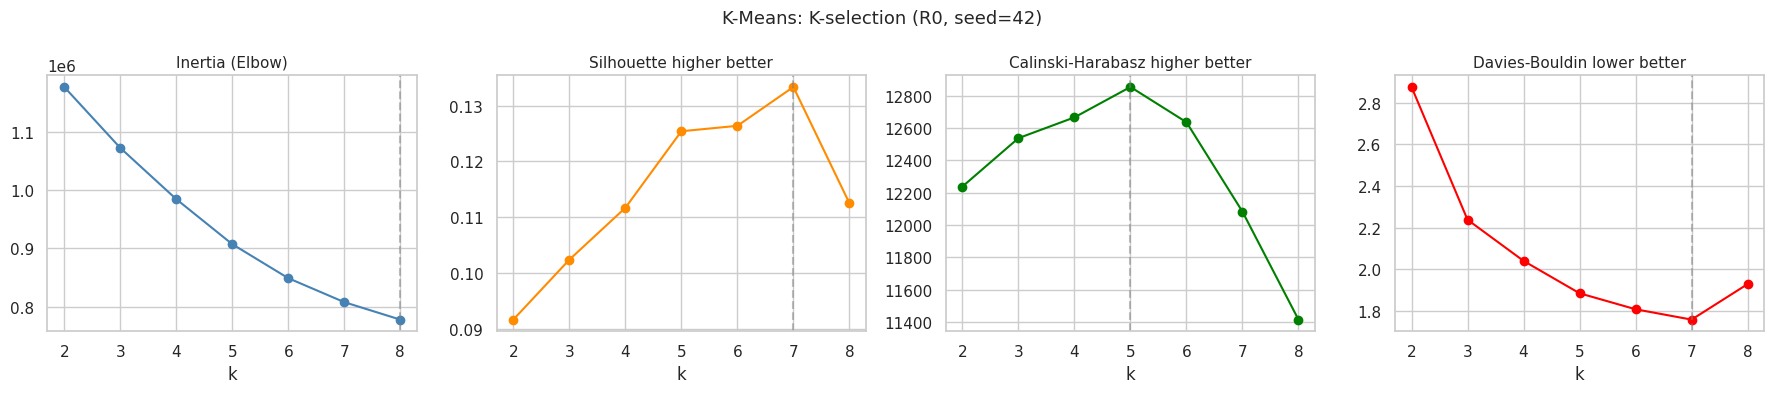

In [ ]:
#fazer graficos das metricas
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
metrics = [('inertia','Inertia (Elbow)','steelblue','lower'),
           ('silhouette','Silhouette higher better','darkorange','higher'),
           ('calinski_harabasz','Calinski-Harabasz higher better','green','higher'),
           ('davies_bouldin','Davies-Bouldin lower better','red','lower')]
for ax, (col, title, color, direction) in zip(axes, metrics):
    ax.plot(df_km.k, df_km[col], 'o-', color=color)
    ax.set_title(title, fontsize=11); ax.set_xlabel('k')
    best = df_km.k[df_km[col].idxmax() if direction=='higher' else df_km[col].idxmin()]
    ax.axvline(best, ls='--', color='grey', alpha=0.5)
plt.suptitle('K-Means: K-selection (R0, seed=42)', fontsize=13)
plt.tight_layout()
plt.savefig('figures/kmeans_k_selection.png', dpi=120, bbox_inches='tight') #guardar figura
plt.show()

Graficos de selecao de k: elbow (inertia), silhouette, CH e DB.
A linha tracejada marca o k optimo segundo cada metrica.
Escolha final: k=7 por Silhouette (principal) confirmado por DB decrescente e CH razoavel.


In [ ]:
#tamanhos dos clusters para o k means com o melhor k
BEST_K = int(df_km.loc[df_km.silhouette.idxmax(), 'k']) #o best k é o que tem a melhor silhouette
print(f'Selected k={BEST_K}')

km_final=KMeans(n_clusters=BEST_K, init='k-means++', n_init=10, random_state=GLOBAL_SEED) #algoritmo com esse melhor k
labels_km=km_final.fit_predict(X_R0) #fit

sizes=pd.Series(labels_km).value_counts().sort_index() #conta quantos valores em cada cluster
print(f'Cluster sizes: {sizes.to_dict()}') #tamanho dos clusters
print(f'Size balance: min={sizes.min()}, max={sizes.max()}, ratio={sizes.max()/sizes.min():.2f}') #ratio do maior e menor cluster

Selected k=7
Cluster sizes: {0: 12953, 1: 20096, 2: 2021, 3: 5847, 4: 39997, 5: 10052, 6: 28244}
Size balance: min=2021, max=39997, ratio=19.79


##iK-Means — Anomalous Cluster Extraction

iK-Means determina k automaticamente, extraindo iterativamente o cluster mais anomalo (o mais afastado da media global) usando uma iteracao de dois centros:
  1. Calcular media global mu e escalas por range de cada feature
  2. Encontrar o ponto mais afastado de mu (seed do cluster anomalo)
  3. Iterar: cada ponto vai para o cluster anomalo se delta(x, c) < delta(x, mu)
  4. Repetir ate convergencia ou ate nenhum cluster de tamanho >= min_size ser encontrado

Distancia normalizada: delta_r(x, ref) = sum_j ((x_j - ref_j) / scale_j)^2
As escalas sao os ranges de cada feature (max - min), com zeros substituidos por 1.


In [ ]:
#ik means

from dataclasses import dataclass
from numpy.typing import NDArray

FloatArray = NDArray[np.float64]


@dataclass(frozen=True)
class APCluster:
   #guarda a estrutura do cluster antes e depois
    indices:list#indices das linhas que pertencem a este cluster
    centroid_raw: FloatArray #centroide original
    centroid_std: FloatArray#centroide no espaço normalizado
    size:int #number of points no cluster
    scatter_pct:float#% of total scatter removida pelo cluster

#calcular estatisticas
def compute_feature_statistics(
    X: FloatArray,
    use_unit_ranges: bool = False
) -> tuple[FloatArray, FloatArray, float]:

    X = np.asarray(X, dtype=np.float64) #formato em numpy float 64
    mean = X.mean(axis=0) #media
    if use_unit_ranges:
        scales = np.ones(X.shape[1], dtype=np.float64) #escala unitaria
    else:
        ranges=X.max(axis=0)-X.min(axis=0) #range de cada feature
        #garantir que cada feature contribui em
        #proporcao
        scales=np.where(ranges == 0, 1.0, ranges).astype(np.float64) #se range for 0 substitui
        #por 1 para nao haver divisoes por zero
    #scatter total baseada na dist normalizada
    diff=(X-mean)/scales # (n, d)
    D = float(np.sum(diff ** 2))
    return mean, scales, D


def normalized_squared_distances(
    X:FloatArray,
    indices:list,
    scales:FloatArray,
    reference:FloatArray
) -> FloatArray:
    Xs= np.asarray(X, dtype=np.float64)[indices] #subset dos dados
    diff=(Xs-reference)/scales #normalizacao
    return np.sum(diff ** 2, axis=1)#soma quadratica por linha


def cluster_centroid(X: FloatArray, indices: list) -> FloatArray:
    return np.asarray(X, dtype=np.float64)[indices].mean(axis=0) #calculo
    #do centroide de um cluster


def separate_cluster(
    X:       FloatArray,
    indices: list,
    scales:  FloatArray,
    a:       FloatArray,
    b:       FloatArray
) -> list:
    X = np.asarray(X, dtype=np.float64)
    da=normalized_squared_distances(X, indices, scales, a) #distancia ao centroide que
    #é candidato (a)
    db=normalized_squared_distances(X, indices, scales, b) #distancia ao centroide de ref (b)
    #o ponto pertence ao cluster se estiver mais perto de a do que de b
    return [idx for idx, d_a, d_b in zip(indices, da, db) if d_a < d_b]


def extract_anomalous_cluster(
    X:                FloatArray,
    indices:          list,
    scales:           FloatArray,
    mean:             FloatArray,
    initial_centroid: FloatArray,
    seed_index:       int,
    tol:              float = 1e-12,
    max_iter:         int   = 10_000
) -> tuple[list, FloatArray]:
    X=np.asarray(X, dtype=np.float64)
    mean = np.asarray(mean, dtype=np.float64)
    c= np.asarray(initial_centroid, dtype=np.float64).copy() #centroide inicial

    S=separate_cluster(X, indices, scales, c, mean) #cluster inicial
    if len(S) == 0:
        return [], c #se estiver vazio acaba
    #iterar ate convergir
    for _ in range(max_iter):
        c_new=cluster_centroid(X, S) #atualizacao do centroide
        S_new=separate_cluster(X, indices, scales, c_new, mean) #atualizacao do cluster
        if len(S_new) == 0:
            break
            #criterio de convergencia:
        if np.max(np.abs(c_new - c)) < tol and set(S_new) == set(S):
            c=c_new
            S=S_new
            break
        c = c_new
        S = S_new

    return S, c


def ikmeans_initialize(
    X: FloatArray,
    min_cluster_size: int,
    tol:float = 1e-12,
    max_iter:int= 10_000,
    use_unit_ranges:bool  = False
) -> tuple[list, FloatArray]:

    X=np.asarray(X, dtype=np.float64)
    n, d = X.shape
    #estatisticas globais
    mean_global, scales, D_total = compute_feature_statistics(X, use_unit_ranges)

    residual= list(range(n)) #pontos que ainda nao foram atribuidos
    ap_clusters= [] #lista de clusters extraidos
    remaining_scatter = D_total

    iteration=0
    while True:
        if len(residual) < min_cluster_size:
            break #se nao houver mais que o minimo para

        #media dos que ficam
        mu = cluster_centroid(X, residual)

        #escolhe o ponto mais distante da media
        dists_from_mu = normalized_squared_distances(X, residual, scales, mu)
        seed_pos= int(np.argmax(dists_from_mu))
        seed_idx= residual[seed_pos]
        c_init= X[seed_idx].copy()

        #extrai cluster anomalo
        S, c_final = extract_anomalous_cluster(
            X, residual, scales, mu, c_init, seed_idx, tol, max_iter)

        if len(S) < min_cluster_size:
            break

        #calcula scatter do cluster
        scatter_S = float(np.sum(((X[S] - c_final) / scales) ** 2))
        scatter_pct = (scatter_S / D_total * 100) if D_total > 0 else 0.0
        #guarda cluster
        ap = APCluster(indices = S,
            centroid_raw = c_final,
            centroid_std= c_final / scales,
            size= len(S),
            scatter_pct= scatter_pct,)
        ap_clusters.append(ap)

        #remove cluster do conjunto residual
        S_set= set(S)
        residual= [i for i in residual if i not in S_set]

        iteration += 1
        print(f'iK-Means iter {iteration}: extracted cluster size={len(S)}, '
              f'scatter_pct={scatter_pct:.2f}%, residual={len(residual)}')
        if len(residual) < min_cluster_size:
            break
#se nenhum cluster for encontrado
    if len(ap_clusters) == 0:
        init_centroids = mean_global.reshape(1, -1)
    else: #junta os centroides para usar em k means
        init_centroids = np.array([c.centroid_raw for c in ap_clusters],
                                   dtype=np.float64)

    print(f'iK-Means: {len(ap_clusters)} anomalous clusters found → '
          f'init_centroids shape = {init_centroids.shape}')
    return ap_clusters, init_centroids


  iK-Means iter 1: extracted cluster size=3531, scatter_pct=17.83%, residual=16469
  iK-Means iter 2: extracted cluster size=3320, scatter_pct=11.77%, residual=13149
  iK-Means iter 3: extracted cluster size=2046, scatter_pct=4.13%, residual=11103
iK-Means: 3 anomalous clusters found → init_centroids shape = (3, 73)
k = 3 anomalous clusters extracted
Runtime=2.2s
init_centroids shape=(3, 73)
{0: 23707, 1: 48354, 2: 47149}

Sil=0.1021  CH=12214  DB=2.4360  t=2.2s
Anomalous cluster summary:
  AP-0: size= 3531  scatter_pct=17.83%
  AP-1: size= 3320  scatter_pct=11.77%
  AP-2: size= 2046  scatter_pct=4.13%


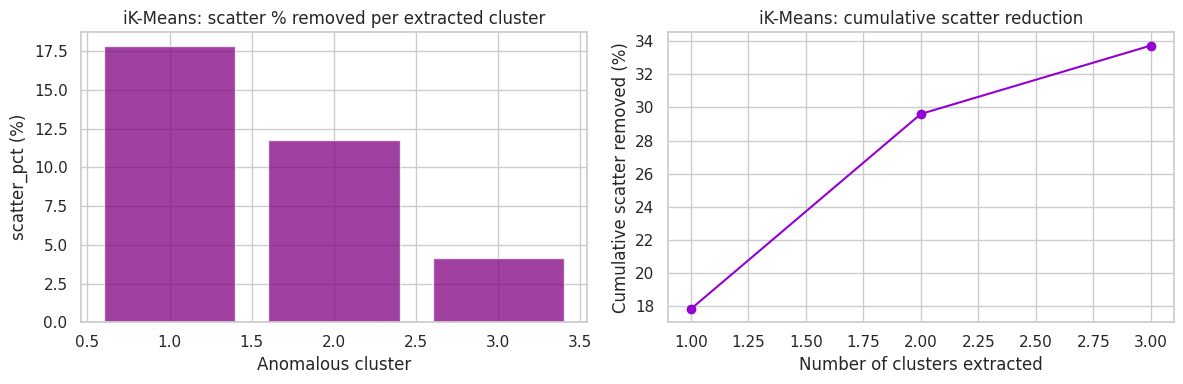

In [ ]:

SUBSAMPLE_IKM = 20000#subsample de 20000 aleatorio
np.random.seed(GLOBAL_SEED) #fixa a seed
ikm_idx=np.random.choice(len(X_R0), size=SUBSAMPLE_IKM, replace=False) #escolhe indices aleatorios
#do tamanho que definimos
X_ikm=X_R0[ikm_idx].astype(np.float64) #cria a subsample

MIN_CLUSTER_SIZE = 10 #minimo tamanho de cluster para evitar cluster pequenos
t0 = time.time() #comeca a contar o tempo
#algoritmo ik means
ap_clusters,init_centroids=ikmeans_initialize(X_ikm,min_cluster_size=MIN_CLUSTER_SIZE,
    tol=1e-12,
    max_iter=10_000,
    use_unit_ranges=False)
ikm_rt=time.time()-t0 #conta o tempo

k_ikm=len(ap_clusters) #numero de clusters encontrados
print(f'k = {k_ikm} anomalous clusters extracted')
print(f'Runtime={ikm_rt:.1f}s')
print(f'init_centroids shape={init_centroids.shape}')

#fazer k means com os centroides de ik means
if k_ikm >= 2: #se forem mais que dois
    km_ikm = KMeans(
        n_clusters=k_ikm,
        init=init_centroids,#iK-Means centroides
        n_init=1, #so uma run
        max_iter=300,
        random_state=GLOBAL_SEED)
    labels_ikm_sub=km_ikm.fit_predict(X_ikm)
    ikm_centroids=km_ikm.cluster_centers_
else:
    #only 1 or 0 clusters found
    #faz com k means ++
    km_ikm = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=GLOBAL_SEED)
    labels_ikm_sub=km_ikm.fit_predict(X_ikm)
    ikm_centroids=km_ikm.cluster_centers_
    k_ikm=2 #valor de k

#atribui cada ponto de XR0 ao centroide do ik means mais proximo
labels_ikm=pairwise_distances_argmin(X_R0, ikm_centroids)
sizes_ikm  = pd.Series(labels_ikm).value_counts().sort_index() #conta numero de pontos por cluster
print(sizes_ikm.to_dict()) #print desses tamanhos

#metricas
sil_ikm=silhouette_score(X_R0, labels_ikm, sample_size=5000, random_state=GLOBAL_SEED)
ch_ikm=calinski_harabasz_score(X_R0, labels_ikm)
db_ikm=davies_bouldin_score(X_R0, labels_ikm)
#print das metricas
print(f'\nSil={sil_ikm:.4f}  CH={ch_ikm:.0f}  DB={db_ikm:.4f}  t={ikm_rt:.1f}s')

#percetagem de scatter por cluster
print('Anomalous cluster summary:')
for i, cl in enumerate(ap_clusters): #para cada cluster do ik menas
    print(f'  AP-{i}: size={cl.size:5d}  scatter_pct={cl.scatter_pct:.2f}%') #tamanho e variancia

pcts = [cl.scatter_pct for cl in ap_clusters] #lista de scatter por cluster
fig, axes = plt.subplots(1, 2, figsize=(12, 4)) #cria figura com 2 graficos lado a lado

#eixos
axes[0].bar(range(1, len(pcts)+1), pcts, color='purple', alpha=0.75)
axes[0].set_xlabel('Anomalous cluster')
axes[0].set_ylabel('scatter_pct (%)')
axes[0].set_title('iK-Means: scatter % removed per extracted cluster')

axes[1].plot(range(1, len(pcts)+1), np.cumsum(pcts), 'o-', color='darkviolet')
axes[1].set_xlabel('Number of clusters extracted')
axes[1].set_ylabel('Cumulative scatter removed (%)')
axes[1].set_title('iK-Means: cumulative scatter reduction')

plt.tight_layout()
plt.savefig('figures/ikmeans_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

## Evaluation and Robustness

In [ ]:
#comparar k means com ik means
compare_rows = [] #lista para colocar resultados
for method, lbl, k in [ #para cada metodo
    ('K-Means', labels_km, BEST_K),
    ('iK-Means', labels_ikm,k_ikm),]:
    #metricas para depois comparar
    sil=silhouette_score(X_R0, lbl, sample_size=5000, random_state=GLOBAL_SEED)
    ch=calinski_harabasz_score(X_R0, lbl)
    db=davies_bouldin_score(X_R0, lbl)
    compare_rows.append({'method':method,'k':k,'silhouette':sil,
                          'calinski_harabasz':ch,'davies_bouldin':db})

df_compare=pd.DataFrame(compare_rows)
display(df_compare.round(4))
df_compare.to_csv('tables/method_comparison.csv', index=False) #guardar em csv

,method,k,silhouette,calinski_harabasz,davies_bouldin
0,K-Means,7,0.1333,12082.8667,1.7578
1,iK-Means,3,0.1021,12214.2121,2.4360


In [ ]:
SEEDS= [42, 7, 13, 99, 2025,40, 60,74,2004,2029] #10 seeds for evaluate stability

#resultados do que escolhemos como melhor opcao k means com k=7
print(f'K-Means stability: 10 seeds, k={BEST_K}')
km_stab_rows, km_stab_labels=[],[] #listas vazias para guardar depois

for seed in SEEDS: #para cada seed
    km_s=KMeans(n_clusters=BEST_K, init='k-means++', n_init=10, random_state=seed) #faz o k means
    lbl=km_s.fit_predict(X_R0) #fit
    #calcular metricas
    sil=silhouette_score(X_R0, lbl, sample_size=5000, random_state=seed)
    ch=calinski_harabasz_score(X_R0, lbl)
    db=davies_bouldin_score(X_R0, lbl)
    #guardar resultados para cada seed
    km_stab_rows.append({'seed':seed,'silhouette':sil,'calinski_harabasz':ch,'davies_bouldin':db})
    km_stab_labels.append(lbl)

#cria df
df_km_stab=pd.DataFrame(km_stab_rows)
display(df_km_stab.round(4)) #com 4 casas decimais
#ver media e desvio padrao com 4 casas decimais
print(df_km_stab[['silhouette','calinski_harabasz','davies_bouldin']].agg(['mean','std']).round(4))
#fazer ari entre seeds para ver estabilidade
ari_km = [adjusted_rand_score(km_stab_labels[i], km_stab_labels[i+1])
          for i in range(len(SEEDS)-1)]
print(f'ARI consecutive seeds: {[round(a,4) for a in ari_km]}') #ari para cada seed
print(f'Mean ARI = {np.mean(ari_km):.4f}') #media de ari

K-Means stability: 5 seeds, k=7


,seed,silhouette,calinski_harabasz,davies_bouldin
0,42,0.1333,12082.8667,1.7578
1,7,0.1404,12082.8669,1.7578
2,13,0.1385,12082.8728,1.7581
3,99,0.1362,12082.8598,1.7582
4,2025,0.1346,12082.8598,1.7582
5,40,0.1344,12082.8675,1.7578
6,60,0.1365,12082.8720,1.7581
7,74,0.1198,11868.3046,1.9514
8,2004,0.1159,11868.2998,1.9514
9,2029,0.1381,12082.8696,1.7579


      silhouette  calinski_harabasz  davies_bouldin
mean      0.1328         12039.9539          1.7967
std       0.0082            90.4684          0.0815
ARI consecutive seeds: [0.9995, 0.9981, 0.9982, 1.0, 0.9967, 0.9982, 0.5597, 0.997, 0.5589]
Mean ARI = 0.9007


In [ ]:
#iK-Means stability analysis
ikm_stab_rows = []   #métricas por run
ikm_labels_all = []  #labels finais por run

for seed in SEEDS:  #varia a seed e para cada uma faz o ik means
    np.random.seed(seed)
    #nova subamostra
    ikm_idx = np.random.choice(len(X_R0), size=SUBSAMPLE_IKM, replace=False)
    X_ikm = X_R0[ikm_idx].astype(np.float64)

    t0 = time.time() #contar o tempo para run time

    #iK-means
    ap_clusters, init_centroids = ikmeans_initialize(
        X_ikm,
        min_cluster_size=MIN_CLUSTER_SIZE,
        tol=1e-12,
        max_iter=10_000,
        use_unit_ranges=False )

    k_ikm = len(ap_clusters)
    #se for maior que 2 clusters faz k means com ik means
    if k_ikm >= 2:
        km_ikm = KMeans(
            n_clusters=k_ikm,
            init=init_centroids,
            n_init=1,
            max_iter=300,
            random_state=seed)
        km_ikm.fit(X_ikm)
        ikm_centroids = km_ikm.cluster_centers_

    else:
        #faz se com k means com k means ++
        km_ikm = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=seed)
        km_ikm.fit(X_ikm)
        ikm_centroids = km_ikm.cluster_centers_
        k_ikm = 2

    #atribuição ao cluster mais proximo
    labels_ikm = pairwise_distances_argmin(X_R0, ikm_centroids)

    # métricas
    sil = silhouette_score(X_R0, labels_ikm, sample_size=5000, random_state=seed)
    ch  = calinski_harabasz_score(X_R0, labels_ikm)
    db  = davies_bouldin_score(X_R0, labels_ikm)

    ikm_stab_rows.append({
        'seed': seed,
        'k': k_ikm,   # importante: k pode variar!
        'silhouette': sil,
        'calinski_harabasz': ch,
        'davies_bouldin': db})

    ikm_labels_all.append(labels_ikm)

#df resultados
df_ikm_stab = pd.DataFrame(ikm_stab_rows)
display(df_ikm_stab.round(4))

#média e desvio padrão
print(df_ikm_stab[['silhouette','calinski_harabasz','davies_bouldin']].agg(['mean','std']).round(4))

#ARI entre runs consecutivas
ari_ikm = [
    adjusted_rand_score(ikm_labels_all[i], ikm_labels_all[i+1])
    for i in range(len(SEEDS)-1)]

print(f'ARI consecutive runs: {[round(a,4) for a in ari_ikm]}')
print(f'Mean ARI = {np.mean(ari_ikm):.4f}')

iK-Means stability: varying subsample (10 seeds)
  iK-Means iter 1: extracted cluster size=3531, scatter_pct=17.83%, residual=16469
  iK-Means iter 2: extracted cluster size=3320, scatter_pct=11.77%, residual=13149
  iK-Means iter 3: extracted cluster size=2046, scatter_pct=4.13%, residual=11103
iK-Means: 3 anomalous clusters found → init_centroids shape = (3, 73)
  iK-Means iter 1: extracted cluster size=3546, scatter_pct=17.95%, residual=16454
  iK-Means iter 2: extracted cluster size=3314, scatter_pct=11.67%, residual=13140
  iK-Means iter 3: extracted cluster size=2004, scatter_pct=4.02%, residual=11136
iK-Means: 3 anomalous clusters found → init_centroids shape = (3, 73)
  iK-Means iter 1: extracted cluster size=3540, scatter_pct=17.80%, residual=16460
  iK-Means iter 2: extracted cluster size=3354, scatter_pct=11.99%, residual=13106
  iK-Means iter 3: extracted cluster size=2003, scatter_pct=4.06%, residual=11103
  iK-Means iter 4: extracted cluster size=1589, scatter_pct=6.31%, 

,seed,k,silhouette,calinski_harabasz,davies_bouldin
0,42,3,0.1021,12214.2121,2.4360
1,7,3,0.1095,12211.9230,2.4399
2,13,4,0.0961,10714.4698,2.4650
3,99,7,0.1119,11001.4977,1.9660
4,2025,8,0.0989,9894.3665,2.1873
5,40,6,0.0943,9462.0855,2.2445
6,60,3,0.1073,12200.4256,2.4460
7,74,6,0.0864,9283.0114,2.3384
8,2004,3,0.1021,12212.7882,2.4334
9,2029,6,0.0963,9455.4812,2.2366


      silhouette  calinski_harabasz  davies_bouldin
mean      0.1005         10865.0261          2.3193
std       0.0077          1276.9534          0.1611
ARI consecutive runs: [0.9633, 0.5459, 0.6194, 0.8684, 0.4315, 0.2588, 0.3141, 0.3137, 0.2933]
Mean ARI = 0.5120


In [ ]:
#r0 vs r1
sens_rows, lbl_dict=[],{} #lista para as metricas e dicionario para as labels
for rep_id, X_rep, scaler_name in [('R0-standard-noADR', X_R0, 'StandardScaler'), #com r0
    ('R1-robust-noADR',   X_R1, 'RobustScaler'),]: #com r1
    km_s=KMeans(n_clusters=BEST_K, init='k-means++', n_init=10, random_state=GLOBAL_SEED) #algoritmo k menas com k means ++
    lbl=km_s.fit_predict(X_rep) #fit
    #metricas para cada uma das ri
    sil=silhouette_score(X_rep, lbl, sample_size=5000, random_state=GLOBAL_SEED)
    ch=calinski_harabasz_score(X_rep, lbl)
    db=davies_bouldin_score(X_rep, lbl)
    #append da ri, o tipo de scaling e as metricas
    sens_rows.append({'representation_id':rep_id,'scaler':scaler_name,
                      'silhouette':sil,'calinski_harabasz':ch,'davies_bouldin':db})
    #guardar labels
    lbl_dict[rep_id] = lbl
#criar df
df_sens = pd.DataFrame(sens_rows)
display(df_sens.round(4)) #mostrar com 4 casas decimais
ari_scale = adjusted_rand_score(lbl_dict['R0-standard-noADR'], lbl_dict['R1-robust-noADR']) #fazer ari
print(f'ARI(R0 vs R1)={ari_scale:.4f}')
df_sens.to_csv('tables/sensitivity_scaler.csv', index=False) #guarda a tabela

,representation_id,scaler,silhouette,calinski_harabasz,davies_bouldin
0,R0-standard-noADR,StandardScaler,0.1333,12082.8667,1.7578
1,R1-robust-noADR,RobustScaler,0.1103,10577.1397,2.1589


ARI(R0 vs R1)=0.2835


In [ ]:

# Sensitivity: with hotel vs without hotel variable
# Tests whether clusters are trivially driven by property type

CATEG_NO_HOTEL= [c for c in CATEGORICAL_FEATURES if c != 'hotel']
ALL_NO_HOTEL= NUMERICAL_FEATURES + BINARY_FEATURES + CATEG_NO_HOTEL

prep_nh = ColumnTransformer([
    ('num', Pipeline([('imp',SimpleImputer(strategy='median')),('sc',StandardScaler())]), NUMERICAL_FEATURES),
    ('bin', 'passthrough', BINARY_FEATURES),
    ('cat', Pipeline([('imp',SimpleImputer(strategy='most_frequent')),
                      ('ohe',OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), CATEG_NO_HOTEL),
])
X_nohotel = prep_nh.fit_transform(df2[ALL_NO_HOTEL])

km_nh   = KMeans(n_clusters=BEST_K, init='k-means++', n_init=10, random_state=GLOBAL_SEED)
lbl_nh  = km_nh.fit_predict(X_nohotel)
sil_nh  = silhouette_score(X_nohotel, lbl_nh, sample_size=5000, random_state=GLOBAL_SEED)
ari_hotel = adjusted_rand_score(labels_km, lbl_nh)

print(f'With hotel   : Sil={silhouette_score(X_R0, labels_km, sample_size=5000, random_state=GLOBAL_SEED):.4f}')
print(f'Without hotel: Sil={sil_nh:.4f}')
print(f'ARI(with vs without hotel) = {ari_hotel:.4f}')
print()

With hotel   : Sil=0.1333
Without hotel: Sil=0.1374
ARI(with vs without hotel) = 0.9113



##Cluster Profiling

In [ ]:
#ver tamanho de cada cluster

df_prof=df2.copy() #copiar o df
df_prof['cluster_km']=labels_km #do k means

CL = 'cluster_km'

print(f'Cluster sizes ({CL}):')
display(df_prof[CL].value_counts().sort_index().rename('n')) #contar tamanho de cada cluster

Cluster sizes (cluster_km):


,n
cluster_km,
0,12953
1,20096
2,2021
3,5847
4,39997
5,10052
6,28244


In [ ]:
#perfil numerico de cada cluster
num_prof_cols = ['lead_time','total_nights','party_size',
                 'previous_cancellations','previous_bookings_not_canceled',
                 'total_of_special_requests','required_car_parking_spaces'] #features numericas
prof_num = df_prof.groupby(CL)[num_prof_cols].agg(['mean','median']).round(2) #fazer media e mediana de cada feature anterior
display(prof_num) #mostrar a tabela
prof_num.to_csv('tables/profile_numerical.csv') #guardar a tabela

lead_time        total_nights        party_size         \
                mean median         mean median       mean median   
cluster_km                                                          
0             139.47  128.0         8.45    7.0       1.98    2.0   
1               5.71    3.0         1.87    1.0       1.61    2.0   
2              14.58    3.0         1.71    1.0       1.21    1.0   
3             213.64  257.0         2.73    2.0       1.84    2.0   
4             147.95  113.0         2.83    3.0       1.80    2.0   
5              88.25   66.0         3.59    3.0       3.45    3.0   
6              85.20   61.0         3.28    3.0       2.01    2.0   

           previous_cancellations        previous_bookings_not_canceled  \
                             mean median                           mean   
cluster_km                                                                
0                            0.00    0.0                           0.01   
1                            0.00    0.0                           0.05   
2                            0.59    0.0                           7.26   
3                            1.56    1.0                           0.02   
4                            0.00    0.0                           0.00   
5                            0.00    0.0                           0.00   
6                            0.00    0.0                           0.01   

                  total_of_special_requests         \
           median                      mean median   
cluster_km                                           
0             0.0                      0.51    0.0   
1             0.0                      0.31    0.0   
2             4.0                      0.74    0.0   
3             0.0                      0.12    0.0   
4             0.0                      0.08    0.0   
5             0.0                      0.59    0.0   
6             0.0                      1.55    1.0   

           required_car_parking_spaces         
                                  mean median  
cluster_km                                     
0                                 0.07    0.0  
1                                 0.13    0.0  
2                                 0.22    0.0  
3                                 0.00    0.0  
4                                 0.02    0.0  
5                                 0.10    0.0  
6                                 0.07    0.0

In [ ]:
#perfil categorico dos clusters
#features categoricas
cat_prof_cols = ['hotel','market_segment','distribution_channel',
                 'deposit_type','customer_type','meal_clean','reserved_room_type','country_grouped']
for col in cat_prof_cols:
    ct = pd.crosstab(df_prof[CL], df_prof[col], normalize='index') * 100 #percentagem da categoria
    #no cluster
    print(f'\n {col} (% within cluster)')
    display(ct.round(1))


 hotel (% within cluster)


hotel,City Hotel,Resort Hotel
cluster_km,,
0,16.9,83.1
1,51.9,48.1
2,49.7,50.3
3,85.1,14.9
4,83.3,16.7
5,67.0,33.0
6,72.6,27.4



 market_segment (% within cluster)


market_segment,Aviation,Complementary,Corporate,Direct,Groups,Offline TA/TO,Online TA,Undefined
cluster_km,,,,,,,,
0,0.2,0.1,1.6,11.9,9.2,35.5,41.6,0.0
1,0.9,2.1,13.7,30.4,5.4,11.1,36.5,0.0
2,1.0,7.8,61.5,15.6,1.2,3.6,9.3,0.0
3,0.1,0.2,3.0,2.1,56.8,28.3,9.5,0.0
4,0.0,0.1,2.1,3.7,34.9,34.6,24.7,0.0
5,0.0,0.3,0.5,15.1,0.8,7.7,75.5,0.0
6,0.0,0.2,0.1,5.3,0.4,3.6,90.2,0.0



 distribution_channel (% within cluster)


...

meal_clean,BB,FB,HB,SC
cluster_km,,,,
0,65.0,1.4,28.7,4.9
1,84.1,0.2,5.1,10.5
2,96.4,0.1,2.2,1.3
3,82.1,1.7,14.6,1.7
4,76.0,1.0,14.1,8.8
5,86.0,0.5,11.8,1.7
6,74.8,0.0,7.0,18.2



 reserved_room_type (% within cluster)


reserved_room_type,A,B,C,D,E,F,G,H,L
cluster_km,,,,,,,,,
0,49.6,0.5,0.9,29.4,15.1,2.9,1.3,0.3,0.0
1,76.4,0.7,0.4,12.9,6.0,2.2,1.1,0.2,0.0
2,84.0,0.5,0.2,7.3,5.1,1.4,1.3,0.0,0.0
3,95.3,0.8,0.1,2.6,0.9,0.2,0.1,0.0,0.0
4,88.4,0.8,0.1,8.2,2.1,0.3,0.1,0.0,0.0
5,22.7,1.0,6.3,28.3,6.3,15.7,14.7,5.0,0.0
6,67.9,1.5,0.2,22.4,6.2,1.1,0.5,0.1,0.0



 country_grouped (% within cluster)


country_grouped,AUT,BEL,BRA,CHE,CN,DEU,ESP,FRA,GBR,IRL,ITA,NLD,Other,PRT,SWE,USA
cluster_km,,,,,,,,,,,,,,,,
0,0.9,1.5,1.2,1.3,1.2,5.4,4.5,5.5,28.0,8.7,1.4,1.8,8.8,28.1,1.0,0.7
1,0.7,1.3,1.4,0.9,0.7,3.1,9.8,6.2,5.7,1.2,2.5,1.7,9.8,52.2,0.6,2.2
2,0.2,0.2,0.1,0.0,0.0,0.1,1.1,1.7,1.4,0.1,0.2,0.3,7.5,86.9,0.0,0.0
3,0.0,0.3,0.1,0.0,0.0,0.1,0.6,0.1,1.7,1.1,0.0,0.0,0.4,95.5,0.1,0.0
4,1.2,1.4,1.3,1.1,1.1,8.3,5.0,8.9,6.7,1.5,3.3,1.1,7.5,49.4,0.8,1.3
5,1.2,2.8,3.5,2.2,1.1,4.9,12.1,10.8,10.1,2.6,5.2,2.2,13.9,23.4,1.3,2.8
6,1.4,3.6,3.3,2.5,1.5,7.6,9.6,13.3,12.5,3.9,4.3,3.0,12.4,17.4,1.1,2.8


In [ ]:
#Post-hoc profiling (leakage variables NOT used to form clusters)
posthoc_num = ['is_canceled','adr','booking_changes']
display(df_prof.groupby(CL)[posthoc_num].agg(['mean','median']).round(3))
print()
print('Cancellation rate per cluster:')
display(df_prof.groupby(CL)['is_canceled'].mean().rename('cancel_rate').round(3))
print()
print('Reservation status distribution (%):')
display((pd.crosstab(df_prof[CL], df_prof['reservation_status'], normalize='index')*100).round(1))
df_prof.groupby(CL)[posthoc_num].agg(['mean','median']).to_csv('tables/profile_posthoc.csv')

is_canceled             adr         booking_changes       
                  mean median     mean  median            mean median
cluster_km                                                           
0                0.328    0.0  101.384   88.00           0.317    0.0
1                0.131    0.0   86.876   80.25           0.221    0.0
2                0.056    0.0   61.455   65.00           0.279    0.0
3                0.990    1.0   77.530   69.00           0.028    0.0
4                0.512    1.0   93.183   90.00           0.181    0.0
5                0.411    0.0  162.259  157.50           0.323    0.0
6                0.241    0.0  111.920  107.10           0.223    0.0


Cancellation rate per cluster:


,cancel_rate
cluster_km,
0,0.328
1,0.131
2,0.056
3,0.990
4,0.512
5,0.411
6,0.241



Reservation status distribution (%):


reservation_status,Canceled,Check-Out,No-Show
cluster_km,,,
0,31.6,67.2,1.2
1,11.3,86.9,1.8
2,4.7,94.4,0.9
3,98.9,1.0,0.1
4,50.3,48.8,0.9
5,40.2,58.9,0.9
6,23.3,75.9,0.8


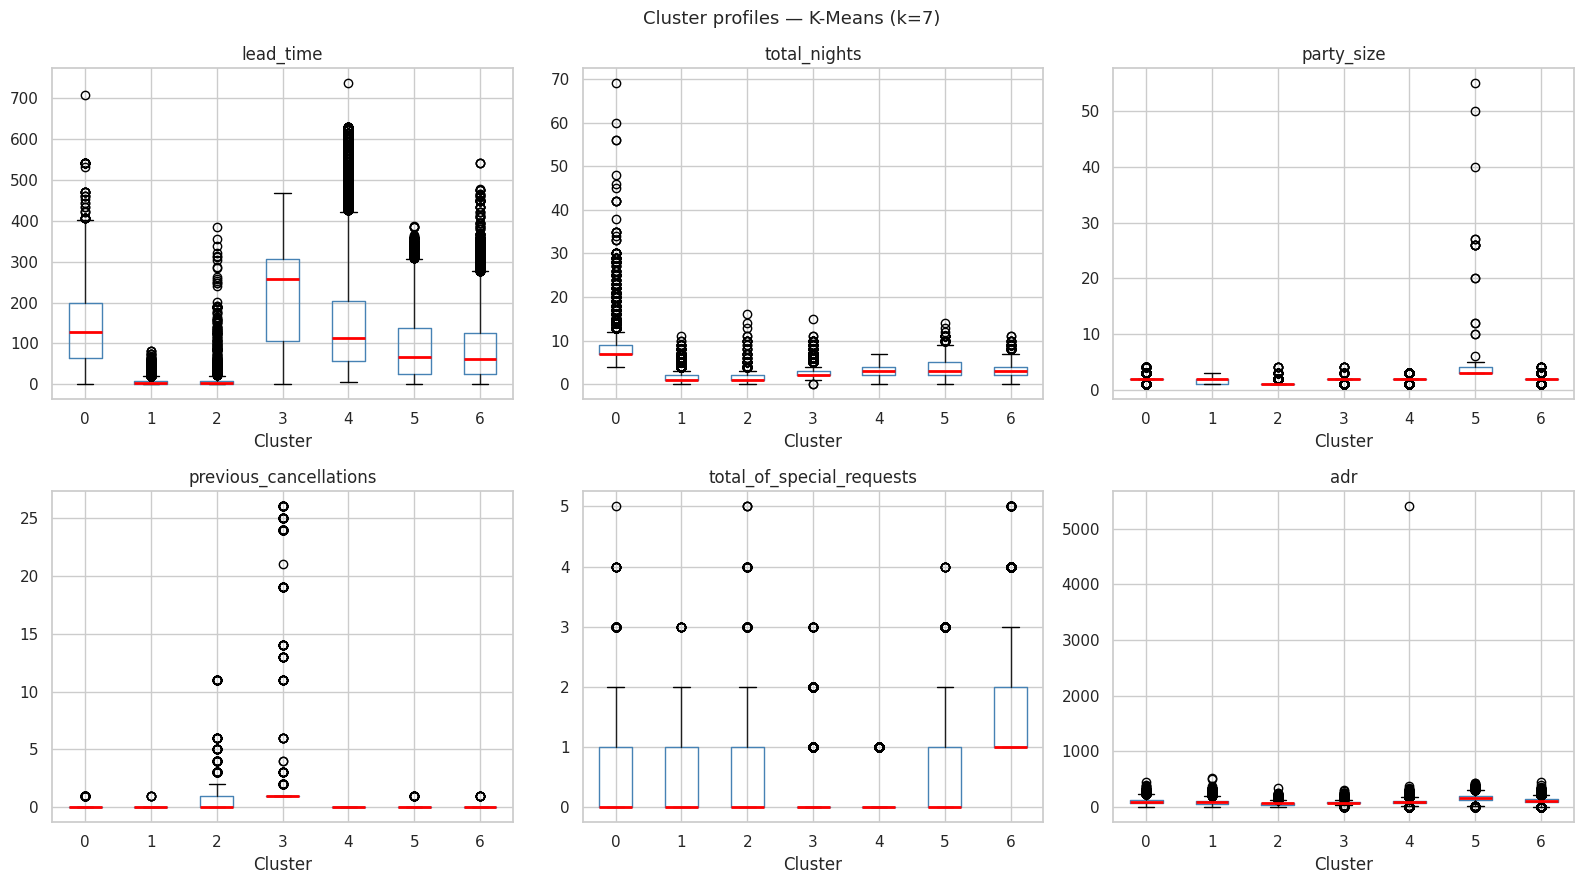

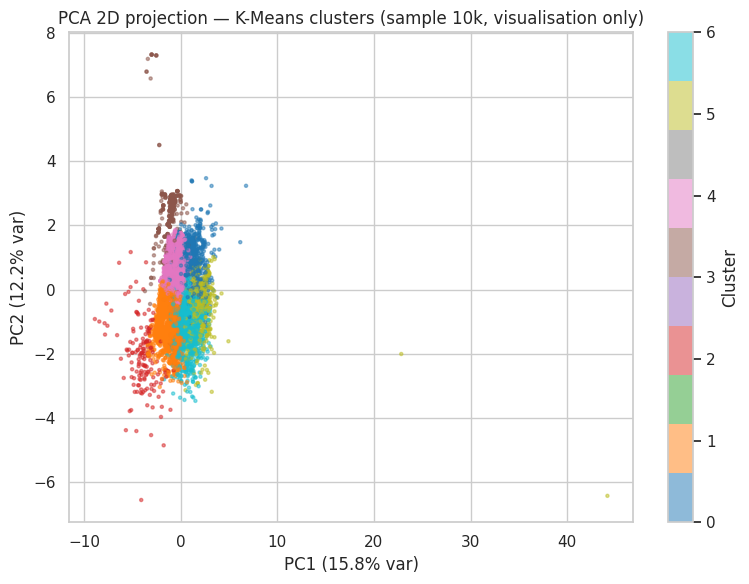

In [ ]:
#perfis visuais dos clusters (graficos)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, ['lead_time','total_nights','party_size',
                                'previous_cancellations','total_of_special_requests','adr']):
    df_prof.boxplot(column=col, by=CL, ax=ax, notch=False,
                    boxprops=dict(color='steelblue'),
                    medianprops=dict(color='red', linewidth=2))
    ax.set_title(col); ax.set_xlabel('Cluster')
plt.suptitle(f'Cluster profiles — K-Means (k={BEST_K})', fontsize=13)
plt.tight_layout()
plt.savefig('figures/profiles_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()

#PCA 2D visualisation
pca2 = PCA(n_components=2, random_state=GLOBAL_SEED) #2 dimensoes
viz_idx = np.random.choice(len(X_R0), 10000, replace=False)
X2d  = pca2.fit_transform(X_R0[viz_idx])
lbl2d = labels_km[viz_idx]
plt.figure(figsize=(8,6))
sc = plt.scatter(X2d[:,0], X2d[:,1], c=lbl2d, cmap='tab10', s=5, alpha=0.5)
plt.colorbar(sc, label='Cluster')
plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)')
plt.title('PCA 2D projection — K-Means clusters (sample 10k, visualisation only)')
plt.tight_layout()
plt.savefig('figures/pca2d_clusters.png', dpi=120, bbox_inches='tight')
plt.show()

##Experiments Log

In [ ]:
import datetime
exp_rows=[] #para guardar

RUN_TS=datetime.datetime.now().strftime('%Y-%m-%dT%H:%M:%S')  #timestamp único por cada vez que corremos

#K-Means k-sweep
for i, r in enumerate(results_km):
    exp_rows.append({
        'run_id': f'km-sweep-k{r["k"]}',
        'date': RUN_TS,
        'method': 'KMeans',
        'representation_id': 'R0-standard-noADR',
        'parameters': f'k={r["k"]}, init=k-means++, n_init=10',
        'sample_rule': 'full dataset',
        'k': r['k'],
        'seed' : GLOBAL_SEED,
        'silhouette': round(r['silhouette'],4),
        'calinski_harabasz': round(r['calinski_harabasz'],2),
        'davies_bouldin': round(r['davies_bouldin'],4),
        'inertia': round(r['inertia'],1),
        'runtime_s': round(r['runtime_s'],2),
        'diagnostics': 'converged',
        'notes' : 'KMeans k-sweep',})

#iK-Means
exp_rows.append({
    'run_id': 'ikmeans-auto',
    'date': RUN_TS,
    'method': 'iKMeans',
    'representation_id': 'R0-standard-noADR',
    'parameters': f'min_cluster_size=10, tol=1e-12, max_iter=10000',
    'sample_rule': f'subsample={SUBSAMPLE_IKM}, seed={GLOBAL_SEED}',
    'k': k_ikm,
    'seed': GLOBAL_SEED,
    'silhouette': round(sil_ikm,4),
    'calinski_harabasz': round(ch_ikm,2),
    'davies_bouldin': round(db_ikm,4),
    'inertia': None,
    'runtime_s': round(ikm_rt,2),
    'diagnostics' : f'{k_ikm} anomalous clusters extracted',
    'notes': f'auto-k; full assign via pairwise_distances_argmin',})

#KMeans stability seeds
for r in km_stab_rows:
    exp_rows.append({
        'run_id': f'km-stab-seed{r["seed"]}',
        'date': RUN_TS,
        'method': 'KMeans-stability',
        'representation_id': 'R0-standard-noADR',
        'parameters': f'k={BEST_K}, init=k-means++, n_init=10',
        'sample_rule': 'full dataset',
        'k': BEST_K,
        'seed' : r['seed'],
        'silhouette': round(r['silhouette'],4),
        'calinski_harabasz': round(r['calinski_harabasz'],2),
        'davies_bouldin': round(r['davies_bouldin'],4),
        'inertia': None,
        'runtime_s': None,
        'diagnostics': 'converged',
        'notes':'seed stability',
    })

#Scaler sensitivity
for r in sens_rows:
    exp_rows.append({
        'run_id'           : f'km-sens-{r["representation_id"]}',
        'date'             : RUN_TS,
        'method'           : 'KMeans-sensitivity',
        'representation_id': r['representation_id'],
        'parameters'       : f'k={BEST_K}, scaler={r["scaler"]}',
        'sample_rule'      : 'full dataset',
        'k'                : BEST_K,
        'seed'             : GLOBAL_SEED,
        'silhouette'       : round(r['silhouette'],4),
        'calinski_harabasz': round(r['calinski_harabasz'],2),
        'davies_bouldin'   : round(r['davies_bouldin'],4),
        'inertia'          : None,
        'runtime_s'        : None,
        'diagnostics'      : 'converged',
        'notes'            : f'scaler={r["scaler"]}',
    })

df_exp = pd.DataFrame(exp_rows)
df_exp.to_csv('experiments.csv', index=False)
print(f'Saved {len(df_exp)} rows to experiments.csv')
display(df_exp.head(8))

## Reproducibility Artefacts

In [ ]:
#Generate environment.yml and run_all.py
env_yml = '''name: hotel-clustering
channels:
  - defaults
  - conda-forge
dependencies:
  - python=3.10
  - numpy>=1.24
  - pandas>=1.5
  - scikit-learn>=1.3
  - scipy>=1.10
  - matplotlib>=3.7
  - seaborn>=0.12
  - jupyter
  - jupyterlab
  - pip
  - pip:
    - yellowbrick
'''

run_all_py = '''#!/usr/bin/env python
"""
run_all.py — single entry-point that regenerates all results.
Usage:
    python run_all.py            # full run
    python run_all.py --fast     # fast-check mode (small subsample)
"""
import subprocess, sys, os

fast = '--fast' in sys.argv
cmd  = ['jupyter', 'nbconvert', '--to', 'notebook', '--execute',
        '--ExecutePreprocessor.timeout=3600',
        'hotel_clustering_complete.ipynb',
        '--output', 'hotel_clustering_complete_executed.ipynb']
if fast:
    print('[FAST MODE] Running notebook with reduced subsamples...')
subprocess.run(cmd, check=True)
print('Done — executed notebook saved to hotel_clustering_complete_executed.ipynb')
print('Figures: ./figures/   Tables: ./tables/   Log: experiments.csv')
'''

with open('environment.yml', 'w') as f: f.write(env_yml)
with open('run_all.py', 'w') as f: f.write(run_all_py)
